# 02805 Social graphs and interactions, Fall 20205 - Assignment 2

#### Søren Stange, s204229 
#### Freja Tusindfryd Dollas, s204248

Coding prerequisites:

In [1]:
#import all necessary libraries and modules
import networkx as nx 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pickle, requests, os, re, random, powerlaw, nltk, string, math
from scipy import stats
from collections import Counter
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

In [2]:
# Download the data from github if not already downloaded
filename = "assignment_1_rock_bands.pkl"

url = "https://raw.githubusercontent.com/sorenstange/02805_Social_graphs_and_interactions/main/assignment_1_rock_bands.pkl"

# Step 1: Check if file exists
if not os.path.exists(filename):
    # Download the file if it does not exist
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    else:
        print(f"Failed to download file. Status code: {response.status_code}")
else:
    print("File already exists. Skipping download.")

# Step 2: Load the .pickle file
with open(filename, "rb") as f:
    wikipedia_data = pickle.load(f)

File already exists. Skipping download.


In [3]:
# Declare helper functions
def clean_links(links):
    arr = []
    for l in links:
        match = re.search(r'|', l)
        if match:
            splits = l.split(r'|')
            arr.append(splits[0].replace(' ', '_'))
        else:
            arr.append(l.replace(' ', '_'))
    return arr

def analyze_node(data_point):
    Node = data_point['page_name']
    text = data_point['content']
    words = len(text.split())
    links_to = re.findall(r'\[\[([^\]]+)\]\]', text)
    links_to = clean_links(links_to)
    return Node, links_to, words

def create_network(data):
    G = nx.DiGraph()
    Nodes = list(set([data_point['page_name'] for data_point in data]))
    Nodes.remove('AllMusic')
    for data_point in data:
        Node, links_to, words = analyze_node(data_point)
        if Node == 'AllMusic':
            continue
        G.add_node(Node, words=words)
        for links_to_node in links_to:
            if links_to_node in Nodes:
                G.add_edge(Node, links_to_node)
    
    # Extract the largest component
    components = nx.weakly_connected_components(G)
    largest = max(components, key=len)
    G = G.subgraph(largest).copy()
    return G


# NB!!!!! this code is done very much with the help of chatGPT as stated is allowed in the weekly assignment. 
def clean_wiki_markup(text):
    if not text:
        return ""
    text = re.sub(r'<!--.*?-->', '', text, flags=re.S)
    text = re.sub(r'\{\{\s*flatlist\s*\|\s*([^}]*)\}\}', lambda m: re.sub(r'\*\s*', ', ', m.group(1)), text, flags=re.I)
    text = re.sub(r'\{\{nowrap\|([^}]*)\}\}', r'\1', text, flags=re.I)
    text = re.sub(r'\{\{[^\}]*\}\}', '', text)
    text = re.sub(r'\[\[(?:[^|\]]*\|)?([^\]]+)\]\]', r'\1', text)
    text = re.sub(r'\[https?:\/\/[^\s\]]+\s*([^\]]*)\]', r'\1', text)
    text = re.sub(r'https?:\/\/\S+', '', text)
    text = re.sub(r'url\s*=\s*\S+', '', text)
    text = re.sub(r'www\.[^\s]+', '', text)
    text = re.sub(r"''+", '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = text.replace('\n', ',').replace('•', ',').replace(';', ',')
    text = re.sub(r'[,/\\|]+', ',', text)
    text = re.sub(r'\s+', ' ', text).strip(' ,')
    return text

def normalize_genre_name(g):
    g = g.lower()
    g = g.replace("rock n roll", "rock and roll")
    g = g.replace("rock'n'roll", "rock and roll")
    g = g.replace("rock ’n’ roll", "rock and roll")
    g = g.replace("psychedelic-rock", "psychedelic rock")
    g = re.sub(r'\s*&\s*', ' and ', g)
    return g.strip()

def split_genres(text):
    if not text:
        return []
    text = re.sub(r'[\n;/]', ',', text)
    text = re.sub(r'\s*\*\s*', ',', text)
    text = re.sub(r'[|]', ',', text)
    genres = [g.strip().lower() for g in text.split(',') if g.strip()]
    blacklist = {
        'artist', 'website', 'label', 'albums', 'musician', 'url=', 
        'www.allmusic.com', 'discogs', 'music', 'genre', '}}', '{{', 
        'nowrap', 'flatlist'
    }
    return [g for g in genres if g not in blacklist and len(g) > 1]

def extract_genre_field(text):
    lines = text.splitlines()
    capture = False
    genre_lines = []
    for line in lines:
        if not capture:
            if re.match(r'\|\s*genre\s*=', line, flags=re.I):
                line = re.sub(r'\|\s*genre\s*=\s*', '', line, flags=re.I)
                genre_lines.append(line)
                capture = True
        else:
            if re.match(r'\|\s*\w+\s*=', line):
                break
            genre_lines.append(line)
    return '\n'.join(genre_lines).strip()

In [4]:
# --- Extract genres from wikipedia_data ---

genres_dict = {}

for entry in wikipedia_data:
    artist_name = entry['page_name']
    text = entry['content']

    raw = extract_genre_field(text)
    if raw:
        cleaned = clean_wiki_markup(raw)
        genres = [normalize_genre_name(g) for g in split_genres(cleaned)]
        if genres:
            genres_dict[artist_name] = genres

# --- Stats ---
num_with_genres = len(genres_dict)
total_genres = sum(len(v) for v in genres_dict.values())
distinct_genres = set(g for gs in genres_dict.values() for g in gs)


# --- Top genres ---
all_genres_flat = [g for gs in genres_dict.values() for g in gs]
genre_counts = Counter(all_genres_flat)
top15 = genre_counts.most_common(15)


# Create the directed graph
G = create_network(wikipedia_data)
nodes_with_genres = [n for n in G.nodes if n in genres_dict]
G_undirected = G.subgraph(nodes_with_genres).to_undirected()


## Part 1: Analyze the network


The questions in this part are based on Lecture 5.

- Present an analysis/description of the network of bands/artists using tools from Lecture 5. Imagine that you have been tasked with presenting the important facts about the network to an audience who knows about network science, but doesn't know about this particular network.
    * It's OK to also use basic concepts like degree distributions (even though they're from week 4) in your analysis. That way you can make the analysis a standalone, coherent thing.
    * I would like you to include concepts like centrality and assortativity in your analysis.
    * Use a network backbone in your analysis.
    * In addition to standard distribution plots (e.g. degree distributions, etc), your analysis should also include at least one network visualization (but it doesn't have to display the entire network, you can also visualize a network backbone).
    * **Note**: As I write above, an important part of the exercise consists is selecting the right elements of the lecture to create a meaningful analysis. So don't solve this part by going exhaustive and just calculating everything you can think of in one massive analysis. Try to focus on using what you've learned to characterize the network.

Jeg tænker at vi skal beskrive: 

- degree distribution + plot both in and out
- centrality (degree, betweenness, eigenvector - maybe scatterplots to compare? )
- assortativity (degree, length of content)
- average shortest path compared to random graph
- network backbone 
- visualization of network (e.g. network backbone)


tilføj hvor mange nodes med genre og hvor mange genre pr node opn average

In [5]:
print(f'Nodes: {len(G.nodes())}')
print(f'Edges: {len(G.edges())}')
print(f'Distinct genres: {len(set(distinct_genres))}')
print(f'\nTop 15 genres')
print('-'*52)
print(f'{"Rank":<5} {"Genre":>20} {"Count":>20}')
print('-'*52)
for i, (genre, count) in enumerate(top15):
    print(f'{i+1:<5} {genre:>20} {count:>20}')


Nodes: 484
Edges: 7321
Distinct genres: 284

Top 15 genres
----------------------------------------------------
Rank                 Genre                Count
----------------------------------------------------
1         alternative rock                  114
2                hard rock                   99
3                 pop rock                   70
4        alternative metal                   51
5              heavy metal                   40
6                     rock                   39
7              post-grunge                   38
8               blues rock                   28
9                      pop                   25
10               soft rock                   23
11        progressive rock                   23
12              indie rock                   21
13               power pop                   21
14               punk rock                   20
15                pop-punk                   20


In [6]:
def create_centrality_table(G, top = 10):
    in_degree = [node for node, _ in sorted([(node, degree) for node, degree in G.in_degree()], key = lambda x: x[1], reverse = True)[:top]]
    out_degree = [node for node, _ in sorted([(node, degree) for node, degree in G.out_degree()], key = lambda x: x[1], reverse = True)[:top]]
    degree_centrality = [node for node, _ in sorted([(node, centrality) for node, centrality in nx.degree_centrality(G).items()], key = lambda x: x[1], reverse = True)[:top]]
    betweenness_centrality = [node for node, _ in sorted([(node, centrality) for node, centrality in nx.betweenness_centrality(G).items()], key = lambda x: x[1], reverse = True)[:top]]
    eigenvector_centrality = [node for node, _ in sorted([(node, centrality) for node, centrality in nx.eigenvector_centrality(G).items()], key = lambda x: x[1], reverse = True)[:top]]

    print(f'{"Rank":<5} {"In-degree":>15} {"Out-degree":>25} {"Degree centrality":>25} {"Betweenness centrality":>25} {"Eigenvector centrality":>25}')
    print('-' * 130)
    for i in range(len(degree_centrality)):
        print(f'{i+1:<5} {in_degree[i]:>15} {out_degree[i]:>25} {degree_centrality[i]:>25} {betweenness_centrality[i]:>25} {eigenvector_centrality[i]:>25}')



In [7]:
create_centrality_table(G)

Rank        In-degree                Out-degree         Degree centrality    Betweenness centrality    Eigenvector centrality
----------------------------------------------------------------------------------------------------------------------------------
1        Led_Zeppelin           Alice_in_Chains              Led_Zeppelin               Deep_Purple              Led_Zeppelin
2           Bob_Dylan               Deep_Purple             Black_Sabbath              Queen_(band)             Black_Sabbath
3        Queen_(band)             Black_Sabbath              Queen_(band)           Alice_in_Chains                 Metallica
4           Metallica               Def_Leppard                 Metallica             Guns_N'_Roses              Queen_(band)
5         David_Bowie               Bryan_Adams                 Bob_Dylan              Led_Zeppelin               Kiss_(band)
6        Jimi_Hendrix             Guns_N'_Roses           Alice_in_Chains              Jimi_Hendrix              

Table X: Meget de samme bands. Det er disse bands som kan karakteriseres som de største inden for rock genren og meget genkendelige brands. Velkendte = mere udførlig side og folk har haft mere lyst til at skrive om dem.

Length of content

In [8]:
def plot_degree_distributions(G, bins=30):
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "figure.titlesize": 16
    })
    

    in_deg = [deg for _, deg in G.in_degree() if deg > 0]
    alpha_in = powerlaw.Fit(in_deg).alpha
    out_deg = [deg for _, deg in G.out_degree() if deg > 0]
    alpha_out = powerlaw.Fit(out_deg).alpha
    deg = [deg for _, deg in G.degree() if deg > 0]
    alpha = powerlaw.Fit(deg).alpha

    # Define shared bin edges
    in_max = max(in_deg)
    out_max = max(out_deg)

    in_bins = np.linspace(0, in_max, bins+1)
    out_bins = np.linspace(0, out_max, bins+1)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 6))

    # In-degree plots (shared bins)
    axes[0].hist(in_deg, bins=in_bins, color="#1f77b4", alpha=0.8, edgecolor="black")
    axes[0].set_title(f"In-degree distribution \nDegree exponent (alpha): {alpha_in:.2f}")

    axes[1].hist(out_deg, bins=out_bins, color="#ff7f0e", alpha=0.8, edgecolor="black")
    axes[1].set_title(f"Out-degree distribution \nDegree exponent (alpha): {alpha_out:.2f}")

    axes[2].hist(deg, bins=out_bins, color="#00c22a", alpha=0.8, edgecolor="black")
    axes[2].set_title(f"Total degree distribution \nDegree exponent (alpha): {alpha:.2f}")

    fig.suptitle("Degree Distributions", fontsize=18, weight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit


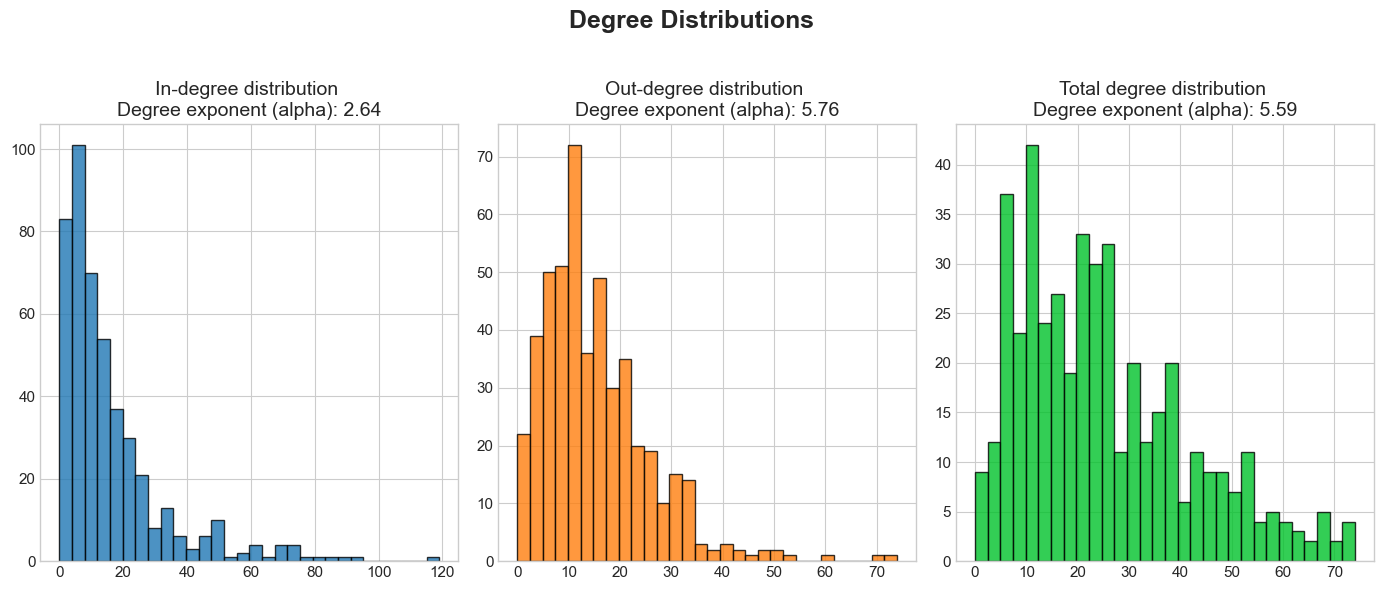

In [9]:
plot_degree_distributions(G)

Figure X: Insert text

In degree exponent is between 2 and 3 many pages link to a few nodes. many hubs. Out degree hubs are less likely to exists 

In [10]:
def plot_centrality_correlations(G):


    degree = dict(G.degree())
    degree_centrality = nx.degree_centrality(G)
    betweenness = nx.betweenness_centrality(G)
    try:
        eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
    except nx.NetworkXError:
        eigenvector = {n: np.nan for n in G.nodes()}


    df = pd.DataFrame({
        "Degree": pd.Series(degree),
        "Degree Centrality": pd.Series(degree_centrality),
        "Betweenness Centrality": pd.Series(betweenness),
        "Eigenvector Centrality": pd.Series(eigenvector)
    })


    plt.style.use("seaborn-v0_8-whitegrid")
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.subplots_adjust(wspace=0.3, hspace=0.3)

    metrics = df.columns

    # --- Plot matrix ---
    for i in range(4):
        for j in range(4):
            ax = axes[i, j]
            if i == j:
                # Diagonal: histogram
                ax.hist(df[metrics[i]], bins=20, color="steelblue", alpha=0.7)
                ax.set_ylabel("")
                ax.set_xlabel(metrics[i], fontsize=10)
            elif i > j:
                # Lower triangle: scatter
                ax.scatter(df[metrics[j]], df[metrics[i]],
                           s=10, alpha=0.6, color="darkslateblue")
                # Add correlation coefficient
                corr = np.corrcoef(df[metrics[j]], df[metrics[i]])[0, 1]
                ax.text(0.05, 0.9, f"r = {corr:.2f}",
                        transform=ax.transAxes, fontsize=8, color="black")
            else:
                # Upper triangle: turn off
                ax.axis("off")

            # Format axes for readability
            ax.tick_params(axis='both', which='major', labelsize=8)
            if j == 0:
                ax.set_ylabel(metrics[i], fontsize=10)
            else:
                ax.set_ylabel("")
            if i < 3:
                ax.set_xlabel("")
            else:
                ax.set_xlabel(metrics[j], fontsize=10)
    
    # --- Title ---
    fig.suptitle("Correlations Between Network Centrality Measures", fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


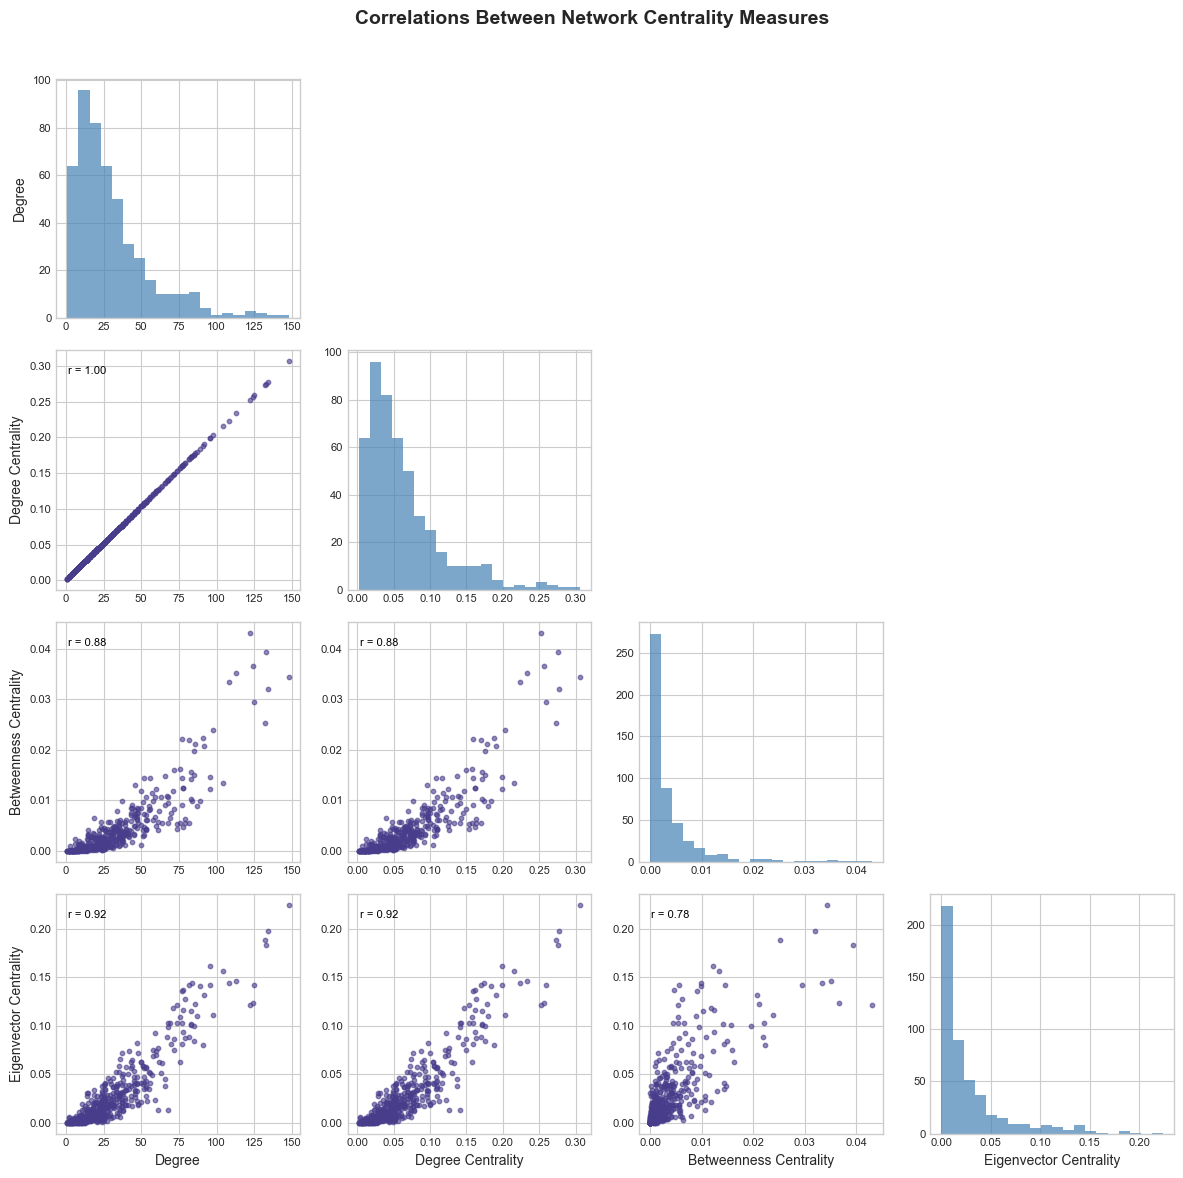

In [11]:
plot_centrality_correlations(G)

Figure X: Tilføj tekst

In [12]:
def disparity_filter(G, alpha_threshold):
    # Create an empty graph of the same type
    backbone = G.__class__()
    backbone.add_nodes_from(G.nodes(data=True))

    # Compute normalized weights and significance for each node
    for i in G.nodes():
        k_i = len(G[i])
        if k_i <= 1:
            continue

        s_i = sum(G[i][j].get('viz_weight', 1.0) for j in G[i])
        for j in G[i]:
            w_ij = G[i][j].get('viz_weight', 1.0)
            p_ij = w_ij / s_i
            alpha_ij = 1 - (1 - p_ij) ** (k_i - 1)
            G[i][j]['alpha_' + str(i)] = alpha_ij

    # For undirected graphs, use the maximum significance (conservative choice)
    if not G.is_directed():
        for i, j, data in G.edges(data=True):
            alpha_i = data.get('alpha_' + str(i), 1)
            alpha_j = data.get('alpha_' + str(j), 1)
            alpha = min(alpha_i, alpha_j)
            if alpha < alpha_threshold:
                backbone.add_edge(i, j, **{'viz_weight': data.get('viz_weight', 1.0), 'alpha': alpha})
    else:
        for i, j, data in G.edges(data=True):
            alpha_i = data.get('alpha_' + str(i), 1)
            if alpha_i < alpha_threshold:
                backbone.add_edge(i, j, **{'viz_weight': data.get('viz_weight', 1.0), 'alpha': alpha_i})

    return backbone


def normalize(x, min_, max_):
    return (x - min_) / (max_ - min_) * 100

def plot_backbone(G, alpha_threshold=0.5, node_size=50, edge_width=1,
                  nodes_cmap=plt.cm.viridis, edge_cmap=plt.cm.Blues):
    G = G.copy()

    plt.figure(figsize=(10,10))

    # Compute betweenness-based visualization weights
    betweenness = nx.edge_betweenness_centrality(G)
    min_bw, max_bw = min(betweenness.values()), max(betweenness.values())
    for (u, v), w in betweenness.items():
        G[u][v]['viz_weight'] = normalize(w, min_bw, max_bw)

    # Extract backbone
    backbone = disparity_filter(G, alpha_threshold)
    
    # Remove nodes with degree less than 5
    to_remove = [n for n, d in backbone.degree() if d < 5]
    backbone.remove_nodes_from(to_remove)

    # Compute node centrality
    centrality = nx.betweenness_centrality(backbone)
    min_c, max_c = min(centrality.values()), max(centrality.values())
    values = [normalize(centrality[n], min_c, max_c) for n in backbone.nodes()]
    # Layout
    pos = nx.forceatlas2_layout(backbone, seed = 42)

    weights = [G[u][v].get('viz_weight', 1.0) for u, v in backbone.edges()]
    # Draw edges
    nx.draw_networkx_edges(backbone, pos, width=edge_width,
                           edge_color=weights, edge_cmap=edge_cmap, alpha=1.)

    # Draw nodes
    nx.draw_networkx_nodes(backbone, pos, node_size=[v + node_size for v in values],
                           node_color=values, cmap=nodes_cmap, alpha=1)

    plt.axis("off")
    plt.title(f"Network Backbone ({backbone.number_of_nodes()} nodes, {backbone.number_of_edges()} edges)")
    plt.show()


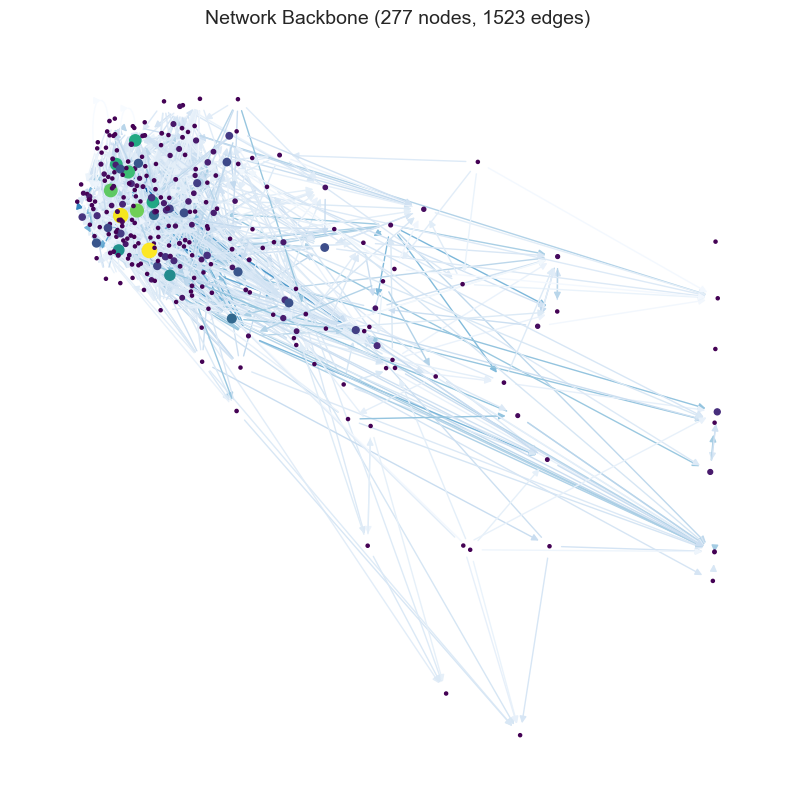

In [13]:
plot_backbone(G, node_size=5, alpha_threshold=0.4)

Figure X: Plot of the backbone of the musician network. Nodes with degree less than 5 are not plotted for visualization purposes. Node color and node size indicates the nodes centrality in accordance to betweeness centrality. The bigger and brighter the node, the higher is the betweeness centrality. Color of the edge corresponds to edge betweeness centrality. Darker lines correspond to higher centrality. In the figure we see how the rock performers network is highly centrilezed around a few performers, and the density of the network becomes smaller as we travel away from these nodes.

## Part 2: Genres and communities and plotting

The questions below are based on Lecture 7, part 2.





##### Question: Write about genres and modularity.
**Answer**: The modularity of networks is a measure of how well a certain partitioning capture the underlying community structure. In this case we derive the genre of each band from the info box on their respective pages and use this information to partition the network. Then we can use the modularity as a measure of how well the partioning actually capture the communities of the network. Modularity is between 1 and 0, and a high modularity implies that partitioning captures the underlying community while a modularity closer to 0 indicates that the partitioning is quite bad. In this case it is a fair assumption that the genres of the rockbands can be an effective measure to capture some of the structure of the communities. 

##### Question: Detect the communities, discuss the value of modularity in comparison to the genres.

**Answer**:


In [14]:
#Firstly the modularity with respect to genre is calculated: 
def calculate_modularity(G, partitions):
    M = 0
    L = len(G.edges())
    if isinstance(partitions, dict):
        for key, nodes in partitions.items():
            subG = G.subgraph(nodes)
            Lc = len(subG.edges())
            kc = sum([deg for _, deg in subG.degree()])
            M += Lc / L - (kc/(2*L))**2
    elif isinstance(partitions, list):
        for nodes in partitions:
            nodes = list(nodes)
            subG = G.subgraph(nodes)
            Lc = len(subG.edges())
            kc = sum([deg for _, deg in subG.degree()])
            M += Lc / L - (kc/(2*L))**2
    
    return M

# Partition by first genre
partition_first = {}
for node in G_undirected.nodes:
    partition_first[node] = genres_dict[node][0]  # first genre

communities_first = {}
for node, com in partition_first.items():
    communities_first.setdefault(com, set()).add(node)

communities_first = list(communities_first.values())


Q_first = calculate_modularity(G_undirected, communities_first)
print(f"Modularity (first genre): {Q_first:.3f}")


# Partition by first non-rock genre
partition_non_rock = {}
for node in G_undirected.nodes:
    non_rock = next((g for g in genres_dict[node] if g != "rock"), genres_dict[node][0])
    partition_non_rock[node] = non_rock

communities_non_rock = {}
for node, com in partition_non_rock.items():
    communities_non_rock.setdefault(com, set()).add(node)
communities_non_rock = list(communities_non_rock.values())


Q_non_rock = calculate_modularity(G_undirected, communities_non_rock)
print(f"Modularity (first non-rock genre): {Q_non_rock:.3f}")


# Partition by random genre from the list
partition_random = {node: random.choice(genres_dict[node]) for node in G_undirected.nodes}

communities_random = {}
for node, com in partition_random.items():
    communities_random.setdefault(com, set()).add(node)
communities_random = list(communities_random.values())

Q_random = calculate_modularity(G_undirected, communities_random)
print(f"Modularity (random genre assignment): {Q_random:.3f}")


Modularity (first genre): 0.139
Modularity (first non-rock genre): 0.134
Modularity (random genre assignment): 0.073


In [15]:
# Compute Louvain communities
communities_louvain = nx.community.louvain_communities(G_undirected, seed=42)

# Compute modularity
Q_louvain = calculate_modularity(G_undirected, communities_louvain)

# Print results
print(f"Detected {len(communities_louvain)} communities")
print(f"Modularity (Louvain): {Q_louvain:.4f}")


Detected 6 communities
Modularity (Louvain): 0.4886


The modularity values for partitioning the network by the first genre, the first non-rock genre, and randomly are 0.139, 0.134, and 0.0754, respectively. Compared to the modularity of 0.3408 obtained using the Louvain algorithm, these values are relatively low, indicating that genre alone is not an effective way of capturing the network’s community structure. However, genre-based partitioning still performs significantly better than a random assignment, which makes sense, since genre does contain some information about connections in the network.

A reason genre may be a poor measure is that many artists have multiple genre labels, and using only the first genre is somewhat arbitrary. Additionally, some genres are very broad, which can obscure community structures. The Louvain algorithm identifies six communities, a much smaller number than the total number of genres, suggesting that the true communities are defined more by the network’s connections than by genre labels. 

Overall these results highligt that while general information, like genre, can provide some insight into the community structure of the netwokr, the community detection is much more efficient. 



##### Question: Calculate the matrix and discuss your findings.
**Answer**:

In [25]:
# Most common genres: 
all_genres = [g for node in G_undirected.nodes for g in genres_dict[node]]  # all genres for nodes in GH
top_genres = pd.Series(all_genres).value_counts().head(7).index.tolist()

#Determine community of genre
node_to_community = {}
for idx, com in enumerate(communities_louvain):
    for node in com:
        node_to_community[node] = idx

# Create confusion matrix
conf_matrix = pd.DataFrame(
    0,
    index=top_genres,
    columns=range(len(communities_louvain))
)

for node in G_undirected.nodes:
    if node not in node_to_community:
        continue
    community = node_to_community[node]
    for genre in genres_dict[node]:
        if genre in top_genres:
            conf_matrix.loc[genre, community] += 1

conf_matrix.columns = [f'Community {i+1}' for i in range(len(communities_louvain))]
print("D: Confusion Matrix (Genres vs Louvain Communities):")
print(conf_matrix)



D: Confusion Matrix (Genres vs Louvain Communities):
                   Community 1  Community 2  Community 3  Community 4  \
alternative rock            23            5           28           52   
hard rock                   29           45           13            2   
pop rock                     6           12            3           30   
alternative metal           21           14           14            2   
heavy metal                  3           33            3            0   
rock                         1            5            1            2   
post-grunge                 28            2            6            2   

                   Community 5  Community 6  
alternative rock             0            6  
hard rock                    0           10  
pop rock                     0           19  
alternative metal            0            0  
heavy metal                  0            1  
rock                         0           30  
post-grunge                  0          

From the confusion matrix above (6 communities and the 7 most common genres), it can be seen that for the genres alternative rock, heavy metal, rock, and post-grunge, there is a noticeably higher number of nodes in one community compared to others. However, all genres have nodes distributed across multiple communities (at least 4 communities for all genres), suggesting that genre alone does not capture the network’s partitioning. Additionally, each community contains multiple genres (except for community 5, which has no nodes from the chosen genres), further showing that community structure is not defined solely by genre. Overall, this suggests that while genre provides some information, it is a poor measure for partitioning the network into communities. This is consistent with the Louvain modularity results as found earlier, where partitioning into communities by the Louvan-algorithm had significantly higher modularity than any genre-based partitioning.

##### Question: Plot the communities and comment on your results.


plot all communitites, color depends on community

## Part 3: TF-IDF to understand genres and communities

The questions below are based on Lecture 7, part 2, 4, 5, 6 (and a little bit on part 3).




##### Question: Explain the concept of TF-IDF in your own words and how it can help you understand the genres and communities.

**Answer**: TF-IDF is a statistical measure which can be used to assess the importance a specific word has in a text or in a collection of texts (corpus). It is the product of two statistics: *term frequency* (TF) and the *inverse document frequency*. TF measures how often a word appears in a single document, wheras IDF measures how rare a word is across a corpus. Thus when a word as a high TF-IDF in a document, it tells us that this word is frequent in the document, but rare in the other documents of the corpus. We can thus use TF-IDF as a measure to extract all the important keywords of a text, that is all the words which characterizes this text.

With this in mind, we can use TF-IDF to extract all the important keywords of the different genres or structural communities from the wikipedia pages, and then analyse the words which are found. This can be especially helpfull if we for instance use an algorithm for finding structural communities such as the Louvain-algorithm, to get more insight in what the community found actually represents. In the context of genre based communities, it can help us understand how the genres are represented in language.

##### Question: Calculate and visualize TF-IDF for the genres and communities.

**Answer**:

In [17]:
# Declare helper functions
def create_corpus(wikipedia_data, partition, filter_n = 5):
    corpus = {}
    if isinstance(partition, dict):
        for key, nodes in partition.items():
            corpus[key] = ''
            for node in nodes:
                for data in wikipedia_data:
                    if data['page_name'] == node:
                        corpus[key] += data['content']

    elif isinstance(partition, list):
        for i, nodes in enumerate(partition):
            key = f'Community {i+1}'
            corpus[key] = ''
            for node in nodes:
                for data in wikipedia_data:
                    if data['page_name'] == node:
                        corpus[key] += data['content'] 

    lemmatizer = WordNetLemmatizer()
    for key, item in corpus.items():
        tokens = word_tokenize(item)
        tokens = [word for word in tokens if word.isalnum()]
        tokens = [word.lower() for word in tokens]
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        word_counts = Counter(tokens)
        tokens = [word for word in tokens if word_counts[word] >= filter_n]
        token_counts = {word: count for word, count in word_counts.items() if count >= filter_n}
        token_counts = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)
        corpus[key] = token_counts
    return corpus

def TF_IDF(corpus):
    corpus = corpus.copy()
    total_number_of_documents = len(corpus)
    word_list = {}
    for key, document in corpus.items():
        for word, amount in document:
            if word not in word_list:
                word_list[word] = 1
            else:
                word_list[word] += 1
    
    for key, document in corpus.items():
        total_number_of_words = sum([amount for _, amount in document])
        new_document = []
        for word, amount in document:
            TF = amount / total_number_of_words
            IDF = np.log(total_number_of_documents / word_list[word])
            new_document.append((word, amount, TF, IDF, TF * IDF))
            
        corpus[key] = sorted(new_document, key = lambda x: x[4], reverse=True)
    
    return corpus

def create_wordclouds(corpus, width = 400, height = 300):

    def normalize(x, a, b):
            return (x-b)/(a-b) * 1000
    n = len(corpus)
    if n == 0:
        print("Corpus is empty.")
        return

    # --- Figure layout ---
    rows = 2  # number of columns in the grid
    cols = math.ceil(n / rows)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 8))
    axes = axes.flatten() if n > 1 else [axes]

    # --- Create word clouds for each community ---
    for i, (key, token_counts) in enumerate(corpus.items()):
        # Convert list of tuples into a frequency dictionary
        TF_IDF_list = [TF_IDF for _,_,_,_,TF_IDF in token_counts]
        max_, min_ = max(TF_IDF_list), min(TF_IDF_list)
        
        freq_dict = []
        for word, _, _, _, TF_IDF in token_counts:
            freq_dict.append((word, normalize(TF_IDF, max_, min_)))
        freq_dict = dict(freq_dict)
        if not freq_dict:
            axes[i].set_visible(False)
            continue

        wc = WordCloud(
            width=width,
            height=height,
            background_color='white',
            colormap='viridis',
            random_state=42
        ).generate_from_frequencies(freq_dict)

        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(key, fontsize=16)
        axes[i].axis('off')

    # --- Hide any unused subplots ---
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


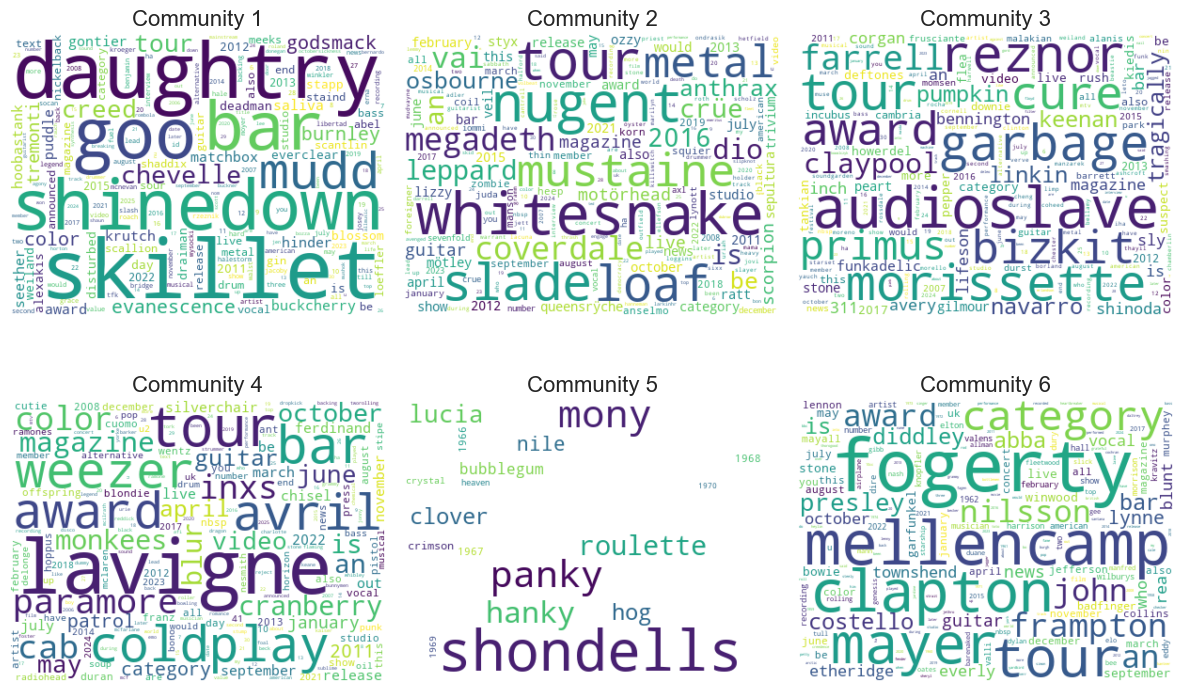

In [18]:
louvain_partition_corpus = create_corpus(wikipedia_data, communities_louvain)

corpus = TF_IDF(louvain_partition_corpus)
create_wordclouds(corpus)

##### Question: Use the matrix D (Lecture 7, part 2) to dicusss the difference between the word-clouds between genres and communities.

## Part 4: Sentiment of the artists and communities

The questions below are based on Lecture 8




##### Question: Calculate the sentiment of the band/artist pages (it is OK to work with the sub-network of artists-with-genre) and describe your findings using stats and visualization, inspired by the first exercise of week 8.

**Answer**:
Notes: Since the words in the LabMT list are not lemmatized (laghs, laughed etc. are included), so therefore the tokens are not lemmatized. Additionally rare words are not filtered out, only lowercase and removal of punctuation. 

In [19]:
#download LabTM list

# Direct URL to the raw LabMT file
url = "https://journals.plos.org/plosone/article/file?id=10.1371/journal.pone.0026752.s001&type=supplementary"

# Download the file
r = requests.get(url)
r.raise_for_status()  # check if download worked
text = r.text

# Split into lines
lines = text.splitlines()

# Skip any lines before the header 
header_index = 0
for i, line in enumerate(lines):
    if line.startswith("word"):
        header_index = i
        break

# Parse the header line
columns = lines[header_index].split('\t')

# Parse the remaining lines into a list of dictionaries
data = []
for line in lines[header_index+1:]:
    values = line.split('\t')
    if len(values) == len(columns):
        data.append(dict(zip(columns, values)))

#  mapping word to happiness_average
word_scores = {row['word']: float(row['happiness_average']) for row in data}



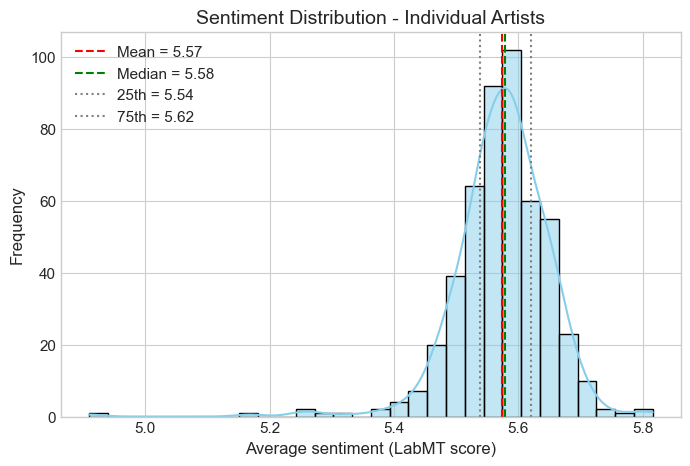

Variance sentiment: 0.0060


In [20]:

def create_corpus2(wikipedia_data, partition, filter_n=1):
    """
    Create a dictionary {community_name: [list of tokens]}.
    Works for either dict- or list-style partitions.
    """
    corpus = {}

    if isinstance(partition, dict):  # e.g. {node: community_id}
        # Convert to community → set of nodes
        community_nodes = {}
        for node, com in partition.items():
            community_nodes.setdefault(com, []).append(node)
    else:
        # Assume already a list of sets/lists
        community_nodes = {i: nodes for i, nodes in enumerate(partition)}


    for key, nodes in community_nodes.items():
        text = ""
        for node in nodes:
            for data in wikipedia_data:
                if data['page_name'] == node:
                    text += data['content'] + " "

        tokens = word_tokenize(text)
        tokens = [t.lower() for t in tokens if t.isalpha()]  

        corpus[key] = tokens

    return corpus



def calculate_sentiment(tokens, word_scores):
    """
    Compute average LabMT sentiment for a list of tokens.
    """
    valid_scores = [word_scores[w] for w in tokens if w in word_scores]
    if not valid_scores:
        return np.nan
    return np.mean(valid_scores)


def sentiment_per_artist(wikipedia_data, word_scores):
    sentiments = {}
    for entry in wikipedia_data:
        tokens = word_tokenize(entry['content'])
        tokens = [t.lower() for t in tokens if t.isalpha()]
        sentiments[entry['page_name']] = calculate_sentiment(tokens, word_scores)
    return sentiments



def sentiment_per_community(corpus, word_scores):
    community_sentiments = {}
    for key, tokens in corpus.items():
        community_sentiments[key] = calculate_sentiment(tokens, word_scores)
    return community_sentiments



def plot_sentiment_distribution(sentiments, title="Sentiment Distribution"):
    values = [v for v in sentiments.values() if not np.isnan(v)]
    mean = np.mean(values)
    median = np.median(values)
    p25, p75 = np.percentile(values, [25, 75])

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=30, kde=True, color='skyblue')
    plt.axvline(mean, color='r', linestyle='--', label=f"Mean = {mean:.2f}")
    plt.axvline(median, color='g', linestyle='--', label=f"Median = {median:.2f}")
    plt.axvline(p25, color='gray', linestyle=':', label=f"25th = {p25:.2f}")
    plt.axvline(p75, color='gray', linestyle=':', label=f"75th = {p75:.2f}")
    plt.legend()
    plt.title(title)
    plt.xlabel("Average sentiment (LabMT score)")
    plt.ylabel("Frequency")
    plt.show()



# Sentiment for each artist
sentiments_artist = sentiment_per_artist(wikipedia_data, word_scores)
plot_sentiment_distribution(sentiments_artist, "Sentiment Distribution - Individual Artists")

values = [v for v in sentiments_artist.values() if not np.isnan(v)]
mean_sent = np.mean(values)
median_sent = np.median(values)
var_sent = np.var(values)
p25, p75 = np.percentile(values, [25, 75])

print(f"Variance sentiment: {var_sent:.4f}")


Figure: A histogram showing the frequency of the average sentiment for all artists pages using LabMT word happiness average with mean, median and 25- and 75- quantile marked. It is clear that the distribution is bell-shaped and quite narrow, meaning that the pages of artist are similiar in regards to happiness/sadness. There are a few pages sadder (below 5), but overall there isn't a large spread. 

In the figure above it is clear that the generel spread of average sentiment is narrow, and the mean and meadian are very close to identical. also 50% of the average sentiments are between 5.54 and 5.62 and with a variance of 0.006 the overall tendency is that the sentiment of different artist pages are very similar. There are a few outliers, mostly below the mean, with lowest values just below 5. 

The narrow spread of the average sentiment implies that across artist pages the emotionel tone of the language tends to be similar - despite differences e.g. in genre. 


##### Question: Discuss the sentiment of the communities. Do the findings using TF-IDF during Lecture 7 help you understand your results?

**Answer**:


--- Community Sentiments ---
Community 0: 5.595
Community 1: 5.539
Community 2: 5.568
Community 3: 5.592
Community 4: 5.498
Community 5: 5.575


C:\Users\soere\AppData\Local\Temp\ipykernel_14680\4238581265.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sentiments_community.keys()), y=list(sentiments_community.values()), palette="coolwarm")


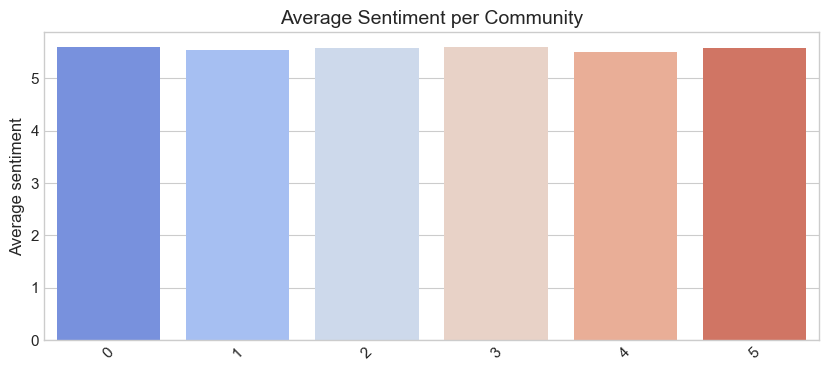

In [ ]:

corpus = create_corpus2(wikipedia_data, communities_louvain)
sentiments_community = sentiment_per_community(corpus, word_scores)

print("\n--- Community Sentiments ---")
for k, v in sentiments_community.items():
    print(f"Community {k+1}: {v:.3f}")

# Bar plot of community sentiment
plt.figure(figsize=(10,4))
sns.barplot(x=list(sentiments_community.keys()), y=list(sentiments_community.values()), palette="coolwarm")
plt.xticks(rotation=45)
plt.ylabel("Average sentiment")
plt.title("Average Sentiment per Community")
plt.show()



### THE END

Contribution: We have each contributed equally to all parts of the assignment. If it is necessary to elaborate it can be somewhat fair to divide as follows: 
- Part 1: Both
- Part 2: Freja Tusindfryd Dollas 
- Part 3: Søren Stange
- Part 4:    